In [50]:
import numpy as np
import pandas as pd
import seaborn as sns
import fathon
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
from fathon import fathonUtils as fu

In [51]:
dataF = np.load('dataF.npy')
dataN = np.load('dataN.npy')
dataO = np.load('dataO.npy')
dataS = np.load('dataS.npy')
dataZ = np.load('dataZ.npy')

folders = [dataZ, dataO, dataN, dataF, dataS]
filenames = ['Z', 'O', 'N', 'F', 'S']
df_filenames = ['Z.csv', 'O.csv', 'N.csv', 'F.csv', 'S.csv']

dfZ = pd.read_csv('Z.csv')
dfO = pd.read_csv('O.csv')
dfN = pd.read_csv('N.csv')
dfF = pd.read_csv('F.csv')
dfS = pd.read_csv('S.csv')

df_folders = [dfZ, dfO, dfN, dfF, dfS]

In [52]:
n = 0
#time series
a = dfZ[f'{n}']

#zero-mean cumulative sum
a = fu.toAggregated(a)

#initialize dfa object
pydfa = fathon.DFA(a)
#compute fluctuation function and Hurst exponent
wins = fu.linRangeByStep(10, 2000)
# wins = np.logspace(np.log10(5), np.log10(4097), 20).astype(np.int64)
n, F = pydfa.computeFlucVec(wins, revSeg=True, polOrd=3)
H, H_intercept = pydfa.fitFlucVec()

#compute Hurst exponent in different ranges
limits_list = np.array([[15,2000], [200,1000]], dtype=int)
list_H, list_H_intercept = pydfa.multiFitFlucVec(limits_list)

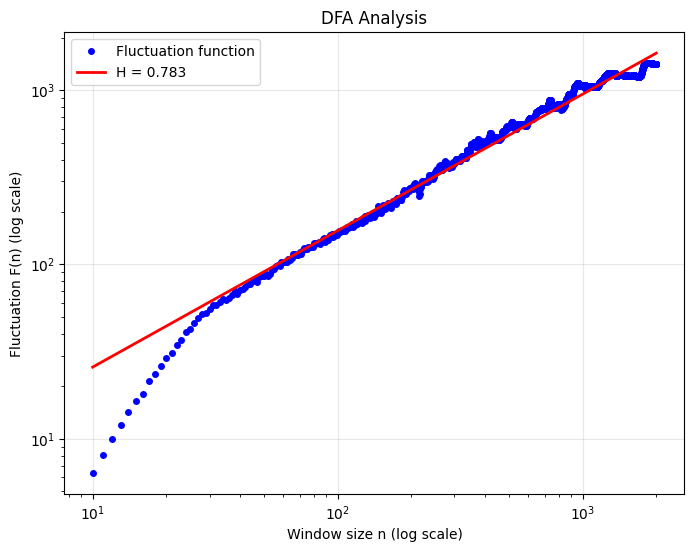

In [53]:
# Simple log-log plot of fluctuation function
plt.figure(figsize=(8, 6))

# Plot the fluctuation function
plt.loglog(n, F, 'o', color='blue', markersize=4, label='Fluctuation function')

# Plot the overall fit line
coeffs = np.polyfit(np.log(n), np.log(F), 1)
fit_line = np.exp(np.polyval(coeffs, np.log(n)))
plt.loglog(n, fit_line, 'r-', linewidth=2, label=f'H = {H:.3f}')

# Labels and title
plt.xlabel('Window size n (log scale)')
plt.ylabel('Fluctuation F(n) (log scale)')
plt.title('DFA Analysis')
plt.legend()
plt.grid(True, alpha=0.3)


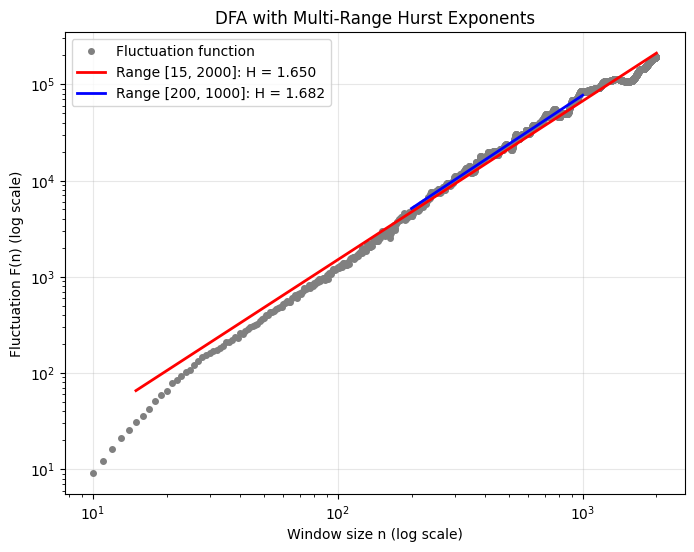

Overall Hurst exponent: 1.6623

Range-specific Hurst exponents:
  Range [15, 2000]: H = 1.6495
  Range [200, 1000]: H = 1.6821


In [54]:
import matplotlib.pyplot as plt
import numpy as np

# Your existing code
a = fu.toAggregated(a)
pydfa = fathon.DFA(a)
wins = fu.linRangeByStep(10, 2000)
n, F = pydfa.computeFlucVec(wins, revSeg=True, polOrd=3)
H, H_intercept = pydfa.fitFlucVec()

limits_list = np.array([[15,2000], [200,1000]], dtype=int)
list_H, list_H_intercept = pydfa.multiFitFlucVec(limits_list)

# ========== SIMPLE PLOT ==========
plt.figure(figsize=(8, 6))

# Plot the fluctuation function
plt.loglog(n, F, 'o', markersize=4, color='gray', label='Fluctuation function')

# Plot the fit lines for each range
colors = ['red', 'blue']
for i, (limits, H_val) in enumerate(zip(limits_list, list_H)):
    # Get the window sizes within this range
    mask = (n >= limits[0]) & (n <= limits[1])
    n_range = n[mask]
    F_range = F[mask]
    
    # Calculate and plot the fit line
    coeffs = np.polyfit(np.log(n_range), np.log(F_range), 1)
    fit_line = np.exp(np.polyval(coeffs, np.log(n_range)))
    plt.loglog(n_range, fit_line, '-', color=colors[i], linewidth=2, 
               label=f'Range [{limits[0]}, {limits[1]}]: H = {H_val:.3f}')

# Labels and legend
plt.xlabel('Window size n (log scale)')
plt.ylabel('Fluctuation F(n) (log scale)')
plt.title('DFA with Multi-Range Hurst Exponents')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Print results
print(f"Overall Hurst exponent: {H:.4f}")
print("\nRange-specific Hurst exponents:")
for i, (limits, H_val) in enumerate(zip(limits_list, list_H)):
    print(f"  Range [{limits[0]}, {limits[1]}]: H = {H_val:.4f}")